# Limpieza, Preparacion y Analisis Exploratorio de Datos

**Datasets:**
- Produccion agricola mensual por regiones (MIDAGRI)
- Variables climaticas por regiones (NASA POWER)

**Regiones:** Ica, Junin, La Libertad, Piura, Puno, San Martin (2020-2025)

**Pipeline:**
- Pasos 1-10: Limpieza y preparacion
- Pasos 11-20: Analisis Exploratorio de Datos (EDA)

## Paso 1 --- Carga de ambos datasets

In [1]:
import pandas as pd
import numpy as np
import unicodedata
import warnings
warnings.filterwarnings('ignore')

# Dataset agricola (MIDAGRI)
df = pd.read_excel('DF_FINAL_2020_2025.xlsx')
print(f'Dataset Agricola: {df.shape}')

# Dataset climatico (NASA POWER)
df_clima = pd.read_excel('Analisis_Climatico_Peru.xlsx')
print(f'Dataset Climatico: {df_clima.shape}')
print(f'\nColumnas agricolas: {len(df.columns)}')
print(f'Columnas climaticas: {len(df_clima.columns)}')

Dataset Agricola: (408, 148)
Dataset Climatico: (432, 17)

Columnas agricolas: 148
Columnas climaticas: 17


## Paso 2 --- Limpieza del dataset agricola

### 2a. Eliminar columnas redundantes
- `Unnamed: 0` (indice residual)
- `region.1` a `region.4` y versiones `_mensual` (100% NaN)
- `anos.1` a `anos.4` y versiones `_mensual` (duplicados)

In [2]:
cols_redundantes = []
for c in df.columns:
    if c == 'Unnamed: 0':
        cols_redundantes.append(c)
    elif 'regi\u00f3n.' in c:
        cols_redundantes.append(c)
    elif 'a\u00f1os.' in c or ('a\u00f1os' in c and c != 'a\u00f1os'):
        cols_redundantes.append(c)

print(f'Columnas redundantes eliminadas: {len(cols_redundantes)}')
df.drop(columns=cols_redundantes, inplace=True)
print(f'Shape despues: {df.shape}')

Columnas redundantes eliminadas: 17
Shape despues: (408, 131)


### 2b. Combinar columnas fragmentadas
Columnas con nombres rotos por formateo de Excel (ej: `espa- rrago`, `limon. sutil`, `pallar gr. seco`).

In [3]:
frag_cols = [c for c in df.columns if '- ' in c or '. ' in c or 'gr.' in c]
print(f'Columnas fragmentadas: {len(frag_cols)}')

def clean_frag_name(name):
    base = name.replace('_mensual', '')
    suffix = '_mensual' if '_mensual' in name else ''
    base = base.replace('gr.', 'grano')
    base = base.replace('- ', '')
    base = base.replace('. ', ' ')
    return base.strip() + suffix

cols_eliminadas = []
for frag in frag_cols:
    destino = clean_frag_name(frag)
    if destino == frag:
        continue
    if destino in df.columns and frag in df.columns:
        df[destino] = df[destino].combine_first(df[frag])
        df.drop(columns=[frag], inplace=True)
        cols_eliminadas.append(frag)
    elif frag in df.columns and destino not in df.columns:
        df.rename(columns={frag: destino}, inplace=True)

# Sinonimos semanticos
sinonimos = {}
for c in list(df.columns):
    if 'haba grano seco' in c:
        dest = c.replace('haba grano seco', 'haba seca')
        if dest in df.columns:
            sinonimos[c] = dest
    elif 'arveja grano seco' in c:
        dest = c.replace('arveja grano seco', 'arveja seca')
        if dest in df.columns:
            sinonimos[c] = dest

for frag, destino in sinonimos.items():
    df[destino] = df[destino].combine_first(df[frag])
    df.drop(columns=[frag], inplace=True)

print(f'Columnas combinadas/renombradas: {len(cols_eliminadas) + len(sinonimos)}')
print(f'Shape despues: {df.shape}')

Columnas fragmentadas: 18
Columnas combinadas/renombradas: 20
Shape despues: (408, 111)


### 2c. Resolver valores negativos en columnas `_mensual`
Los valores negativos representan correcciones retroactivas o errores de redondeo. Se reemplazan por NaN y luego por 0.

In [4]:
mensual_cols = [c for c in df.columns if '_mensual' in c]

# Reemplazar negativos por NaN
total_neg = 0
for c in mensual_cols:
    mask = df[c] < 0
    n = mask.sum()
    if n > 0:
        df.loc[mask, c] = np.nan
        total_neg += n
print(f'Valores negativos reemplazados por NaN: {total_neg}')

# Rellenar NaN con 0 (justificacion: produccion mensual no puede ser negativa)
nan_antes = df[mensual_cols].isnull().sum().sum()
df[mensual_cols] = df[mensual_cols].fillna(0)
print(f'NaN rellenados con 0: {nan_antes}')
print(f'NaN restantes en todo el DataFrame: {df.isnull().sum().sum()}')

Valores negativos reemplazados por NaN: 227
NaN rellenados con 0: 227
NaN restantes en todo el DataFrame: 0


## Paso 3 --- Limpieza del dataset climatico

Valores `-999` de NASA POWER representan datos no disponibles. Se reemplazan por NaN y se interpolan por region.

In [5]:
# Tratar -999 de NASA
cols_num_clima = df_clima.select_dtypes(include='number').columns.tolist()
cols_num_clima = [c for c in cols_num_clima if c != 'Fecha']
n_999 = (df_clima[cols_num_clima] == -999).sum().sum()
print(f'Valores -999 encontrados: {n_999}')
df_clima[cols_num_clima] = df_clima[cols_num_clima].replace(-999, np.nan)

# Extraer ano y mes de la columna Fecha (formato YYYYMM)
df_clima['anos'] = df_clima['Fecha'] // 100
df_clima['mes_num'] = df_clima['Fecha'] % 100

# Mapear departamento a region (resolver tildes)
depto_to_region = {'Piura': 'Piura', 'La Libertad': 'La Libertad', 'Ica': 'Ica', 'Puno': 'Puno'}
for d in df_clima['Departamento'].unique():
    d_clean = unicodedata.normalize('NFKD', d).encode('ascii', 'ignore').decode()
    if 'junin' in d_clean.lower():
        depto_to_region[d] = 'Junin'
    elif 'san martin' in d_clean.lower():
        depto_to_region[d] = 'San Martin'
df_clima['region'] = df_clima['Departamento'].map(depto_to_region)

# Mapear mes numerico a nombre
mes_map = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril', 5:'Mayo', 6:'Junio',
           7:'Julio', 8:'Agosto', 9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'}
df_clima['mes'] = df_clima['mes_num'].map(mes_map)

# Eliminar columnas auxiliares
df_clima.drop(columns=['Fecha', 'Departamento', 'Distrito', 'mes_num'], inplace=True)

# Interpolar NaN por region
for c in df_clima.select_dtypes(include='number').columns:
    if df_clima[c].isnull().any():
        df_clima[c] = df_clima.groupby('region')[c].transform(
            lambda x: x.interpolate(method='linear').ffill().bfill()
        )

print(f'Shape clima procesado: {df_clima.shape}')
print(f'NaN restantes: {df_clima.isnull().sum().sum()}')
print(f'Columnas: {list(df_clima.columns)}')

Valores -999 encontrados: 6
Shape clima procesado: (432, 17)
NaN restantes: 0
Columnas: ['ALLSKY_SFC_SW_DWN', 'GWETROOT', 'PRECTOTCORR', 'PS', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'TS', 'WS2M', 'Amplitud_Termica', 'Riesgo_Helada', 'Estres_Calor', 'VPD_kPa', 'anos', 'region', 'mes']


## Paso 4 --- Estandarizacion de nombres de columnas

In [6]:
def normalize_col(name):
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode()
    name = name.lower().strip()
    name = name.replace('  ', ' ').replace(' ', '_')
    name = name.replace('.', '').replace('-', '')
    return name

# Resolver colisiones en dataset agricola
new_names = [normalize_col(c) for c in df.columns]
from collections import Counter
dupes = [n for n, cnt in Counter(new_names).items() if cnt > 1]

if dupes:
    print(f'Colisiones detectadas: {dupes}')
    seen = {}
    cols_to_drop = []
    for old_name, new_name in zip(df.columns, new_names):
        if new_name in seen:
            df[seen[new_name]] = df[seen[new_name]].combine_first(df[old_name])
            cols_to_drop.append(old_name)
        else:
            seen[new_name] = old_name
    df.drop(columns=cols_to_drop, inplace=True)

df.columns = [normalize_col(c) for c in df.columns]
df_clima.columns = [normalize_col(c) for c in df_clima.columns]

print(f'Agricola: {len(df.columns)} columnas, duplicados: {df.columns[df.columns.duplicated()].tolist()}')
print(f'Clima: {len(df_clima.columns)} columnas, duplicados: {df_clima.columns[df_clima.columns.duplicated()].tolist()}')

Agricola: 111 columnas, duplicados: []
Clima: 17 columnas, duplicados: []


## Paso 5 --- Integracion (merge) de ambos datasets

Se realiza un left join entre el dataset agricola y el climatico usando la clave `(region, anos, mes)`.

In [7]:
print(f'Antes del merge:')
print(f'  Agricola: {df.shape}')
print(f'  Clima:    {df_clima.shape}')

df = df.merge(df_clima, on=['region', 'anos', 'mes'], how='left')

print(f'\nDespues del merge:')
print(f'  Integrado: {df.shape}')
print(f'  NaN: {df.isnull().sum().sum()}')
print(f'  Filas duplicadas: {df.duplicated().sum()}')

Antes del merge:
  Agricola: (408, 111)
  Clima:    (432, 17)

Despues del merge:
  Integrado: (408, 125)
  NaN: 0
  Filas duplicadas: 0


## Paso 6 --- Documentacion de ceros y meses faltantes

### 6a. Ceros legitimos
Los ceros representan productos que no se cultivan en determinadas regiones.

In [8]:
meta_cols = ['region', 'anos', 'mes']
clima_cols = ['allsky_sfc_sw_dwn', 'gwetroot', 'prectotcorr', 'ps', 'rh2m',
             't2m', 't2m_max', 't2m_min', 'ts', 'ws2m', 'amplitud_termica',
             'riesgo_helada', 'estres_calor', 'vpd_kpa']
prod_cols = [c for c in df.columns if c not in meta_cols and c not in clima_cols and '_mensual' not in c]

zero_info = []
for c in prod_cols:
    n_zeros = (df[c] == 0).sum()
    pct = round(n_zeros / len(df) * 100, 1)
    zero_info.append({'columna': c, 'n_ceros': n_zeros, 'pct_ceros': pct})

zero_df = pd.DataFrame(zero_info).sort_values('pct_ceros', ascending=False)
high_zero = zero_df[zero_df['pct_ceros'] > 50]
print(f'Columnas con >50% ceros: {len(high_zero)}')
print(high_zero.to_string(index=False))

Columnas con >50% ceros: 19
          columna  n_ceros  pct_ceros
       maiz_chala      340       83.3
   palma_aceitera      340       83.3
         aceituna      306       75.0
pallar_grano_seco      304       74.5
          tangelo      299       73.3
         piquillo      295       72.3
     algodon_rama      285       69.9
        alcachofa      279       68.4
          oregano      278       68.1
        esparrago      272       66.7
 cana_para_azucar      272       66.7
 cebada_forrajera      249       61.0
         pimiento      222       54.4
         arandano      220       53.9
  avena_forrajera      216       52.9
          paprika      216       52.9
          manzana      210       51.5
      arveja_seca      208       51.0
           quinua      207       50.7


### 6b. Meses faltantes

In [9]:
cobertura = df.groupby(['region', 'anos'])['mes'].count().reset_index()
cobertura.columns = ['region', 'ano', 'n_meses']
incompletos = cobertura[cobertura['n_meses'] < 12]

if len(incompletos) > 0:
    print('Periodos con meses faltantes:')
    print(incompletos.to_string(index=False))
else:
    print('Todos los periodos tienen 12 meses completos')

Periodos con meses faltantes:
     region  ano  n_meses
        Ica 2020       11
        Ica 2021       11
        Ica 2022       11
        Ica 2023       11
      Junin 2020       11
      Junin 2021       11
      Junin 2022       11
      Junin 2023       11
La Libertad 2020       11
La Libertad 2021       11
La Libertad 2022       11
La Libertad 2023       11
      Piura 2020       11
      Piura 2021       11
      Piura 2022       11
      Piura 2023       11
       Puno 2020       11
       Puno 2021       11
       Puno 2022       11
       Puno 2023       11
 San Martin 2020       11
 San Martin 2021       11
 San Martin 2022       11
 San Martin 2023       11


## Paso 7 --- Justificacion: no tratamiento de valores atipicos (outliers)

Se decidio **no aplicar tratamiento de outliers** por las siguientes razones:

### 1. Distribucion bimodal por especializacion regional
El 50-80% de los valores en muchas columnas son ceros legitimos. IQR o Z-score calcularian un rango de 0 y marcarian cualquier produccion real como atipica.

### 2. Variacion inter-regional legitima
Las diferencias de escala entre regiones son naturales. Piura produce ~580,000 tn de arroz mientras que Ica produce 0. Esto refleja especializacion agricola, no outliers.

### 3. Estacionalidad en datos acumulados
Las columnas base son acumulativas. Los valores de Diciembre siempre seran los mas altos, es comportamiento esperado.

### 4. Los valores extremos son datos reales
En produccion agricola, los picos y caidas son causados por factores reales: cosechas excepcionales, sequias, plagas, El Nino. Eliminarlos distorsionaria la realidad.

### Conclusion
Si en etapas posteriores de modelado se requiere robustez ante outliers, se recomienda usar modelos inherentemente robustos (Random Forest, XGBoost, arboles de decision).

## Paso 8 --- Separar en dataset acumulado y mensual

In [10]:
meta = ['region', 'anos', 'mes']
mensual_cols = [c for c in df.columns if '_mensual' in c]
acum_cols = [c for c in df.columns if c not in meta and '_mensual' not in c and c not in clima_cols]

# Dataset acumulado: meta + produccion acumulada + clima
df_acumulado = df[meta + acum_cols + clima_cols].copy()

# Dataset mensual: meta + produccion mensual (sin sufijo) + clima
df_mensual = df[meta + mensual_cols + clima_cols].copy()
df_mensual.columns = [c.replace('_mensual', '') if '_mensual' in c else c for c in df_mensual.columns]

print(f'Dataset Acumulado: {df_acumulado.shape}')
print(f'Dataset Mensual:   {df_mensual.shape}')

Dataset Acumulado: (408, 71)
Dataset Mensual:   (408, 71)


## Paso 9 --- Escalamiento con RobustScaler (dataset mensual)

Se aplica `RobustScaler` sobre las columnas numericas de produccion.
Usa la mediana y el rango intercuartilico (IQR), robusto ante asimetria y ceros.

Formula: `X_scaled = (X - mediana) / IQR`

In [11]:
from sklearn.preprocessing import RobustScaler

# Solo escalar columnas de produccion, NO las climaticas ni metadata
prod_cols_mensual = [c for c in df_mensual.columns if c not in meta and c not in clima_cols]

print(f'Columnas de produccion a escalar: {len(prod_cols_mensual)}')
print(f'Columnas climaticas (no se escalan): {len(clima_cols)}')

scaler = RobustScaler()
df_mensual_scaled = df_mensual.copy()
df_mensual_scaled[prod_cols_mensual] = scaler.fit_transform(df_mensual[prod_cols_mensual])

print(f'\nShape escalado: {df_mensual_scaled.shape}')
print(f'NaN: {df_mensual_scaled.isnull().sum().sum()}')

Columnas de produccion a escalar: 54
Columnas climaticas (no se escalan): 14

Shape escalado: (408, 71)
NaN: 0


## Paso 10 --- Exportacion de datasets finales

In [12]:
# Dataset limpio completo (acumulado + mensual + clima)
df.to_excel('DF_LIMPIO_2020_2025.xlsx', index=False)
df.to_csv('DF_LIMPIO_2020_2025.csv', index=False)

# Dataset acumulado + clima
df_acumulado.to_excel('DF_ACUMULADO_2020_2025.xlsx', index=False)
df_acumulado.to_csv('DF_ACUMULADO_2020_2025.csv', index=False)

# Dataset mensual + clima
df_mensual.to_excel('DF_MENSUAL_2020_2025.xlsx', index=False)
df_mensual.to_csv('DF_MENSUAL_2020_2025.csv', index=False)

# Dataset mensual escalado + clima
df_mensual_scaled.to_excel('DF_MENSUAL_SCALED_2020_2025.xlsx', index=False)
df_mensual_scaled.to_csv('DF_MENSUAL_SCALED_2020_2025.csv', index=False)

# Dataset integrado (mensual + clima, sin escalar)
df_mensual.to_excel('DF_INTEGRADO_2020_2025.xlsx', index=False)
df_mensual.to_csv('DF_INTEGRADO_2020_2025.csv', index=False)

print('Datasets exportados:')
print(f'  DF_LIMPIO_2020_2025          -> {df.shape}')
print(f'  DF_ACUMULADO_2020_2025       -> {df_acumulado.shape}')
print(f'  DF_MENSUAL_2020_2025         -> {df_mensual.shape}')
print(f'  DF_MENSUAL_SCALED_2020_2025  -> {df_mensual_scaled.shape}')
print(f'  DF_INTEGRADO_2020_2025       -> {df_mensual.shape}')

Datasets exportados:
  DF_LIMPIO_2020_2025          -> (408, 125)
  DF_ACUMULADO_2020_2025       -> (408, 71)
  DF_MENSUAL_2020_2025         -> (408, 71)
  DF_MENSUAL_SCALED_2020_2025  -> (408, 71)
  DF_INTEGRADO_2020_2025       -> (408, 71)


In [13]:
# Resumen final
print('RESUMEN DE LIMPIEZA')
print(f'Shape original agricola:   (408, 148)')
print(f'Shape original climatico:  (432, 17)')
print(f'Shape final integrado:     {df.shape}')
print(f'NaN totales: {df.isnull().sum().sum()}')
print(f'Duplicados: {df.duplicated().sum()}')
print(f'\nColumnas ({len(df.columns)}):')  
for i, c in enumerate(df.columns):
    print(f'  {i:3d}. {c}')

RESUMEN DE LIMPIEZA
Shape original agricola:   (408, 148)
Shape original climatico:  (432, 17)
Shape final integrado:     (408, 125)
NaN totales: 0
Duplicados: 0

Columnas (125):
    0. region
    1. anos
    2. trigo
    3. maiz_a_duro
    4. maiz_amilaceo
    5. arroz_cascara
    6. cebada_grano
    7. quinua
    8. esparrago
    9. alcachofa
   10. aji
   11. piquillo
   12. pimiento
   13. tomate
   14. zapallo
   15. arveja_verde
   16. zanahoria
   17. ajo
   18. cebolla
   19. maiz_choclo
   20. palta
   21. platano
   22. mango
   23. papaya
   24. pina
   25. granadilla
   26. limon_sutil
   27. naranja
   28. mandarina
   29. tangelo
   30. uva
   31. manzana
   32. melocoton
   33. tuna
   34. aceituna
   35. palma_aceitera
   36. papa
   37. yuca
   38. camote
   39. oca
   40. olluco
   41. cafe_pergamino
   42. cacao
   43. paprika
   44. frijol_grano_seco
   45. pallar_grano_seco
   46. haba_seca
   47. arveja_seca
   48. cana_para_azucar
   49. alfalfa
   50. maiz_chala

In [14]:
df_mensual.head()

,region,anos,mes,trigo,maiz_a_duro,maiz_amilaceo,arroz_cascara,cebada_grano,quinua,esparrago,...,rh2m,t2m,t2m_max,t2m_min,ts,ws2m,amplitud_termica,riesgo_helada,estres_calor,vpd_kpa
0,Ica,2020,Enero,0.0,9000.19,0.0,0.0,0.0,0.0,14799.600,...,78.45,21.96,27.55,18.21,23.95,2.99,9.34,0,0,0.568361
1,Ica,2020,Febrero,0.0,12378.10,10.6,0.0,0.0,0.0,15070.670,...,79.22,22.85,27.98,19.51,24.72,2.84,8.47,0,0,0.578507
2,Ica,2020,Marzo,0.0,8992.65,0.0,0.0,0.0,0.0,14653.400,...,78.16,22.62,27.86,19.17,24.34,2.70,8.69,0,0,0.599600
3,Ica,2020,Abril,0.0,11051.15,23.7,0.0,0.0,0.0,14738.570,...,73.38,21.48,27.26,16.69,22.83,2.70,10.57,0,0,0.681791
4,Ica,2020,Mayo,0.0,0.00,0.0,0.0,0.0,0.0,14070.719,...,69.33,20.00,25.60,15.49,20.76,2.54,10.11,0,0,0.717127


In [15]:
df_mensual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 71 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   region             408 non-null    object 
 1   anos               408 non-null    int64  
 2   mes                408 non-null    object 
 3   trigo              408 non-null    float64
 4   maiz_a_duro        408 non-null    float64
 5   maiz_amilaceo      408 non-null    float64
 6   arroz_cascara      408 non-null    float64
 7   cebada_grano       408 non-null    float64
 8   quinua             408 non-null    float64
 9   esparrago          408 non-null    float64
 10  alcachofa          408 non-null    float64
 11  aji                408 non-null    float64
 12  piquillo           408 non-null    float64
 13  pimiento           408 non-null    float64
 14  tomate             408 non-null    float64
 15  zapallo            408 non-null    float64
 16  arveja_verde       408 non

---
# ANALISIS EXPLORATORIO DE DATOS (EDA)

Se trabaja con `df_mensual` (produccion mensual + variables climaticas, 408 x 71).

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

meta = ["region", "anos", "mes"]
clima_cols = ["allsky_sfc_sw_dwn", "gwetroot", "prectotcorr", "ps", "rh2m",
             "t2m", "t2m_max", "t2m_min", "ts", "ws2m", "amplitud_termica",
             "riesgo_helada", "estres_calor", "vpd_kpa"]
prod_cols = [c for c in df_mensual.columns if c not in meta and c not in clima_cols]

print(f"Columnas de produccion: {len(prod_cols)}")
print(f"Columnas climaticas: {len(clima_cols)}")


Columnas de produccion: 54
Columnas climaticas: 14


## Grafico 1 --- Top 10 productos por produccion total acumulada

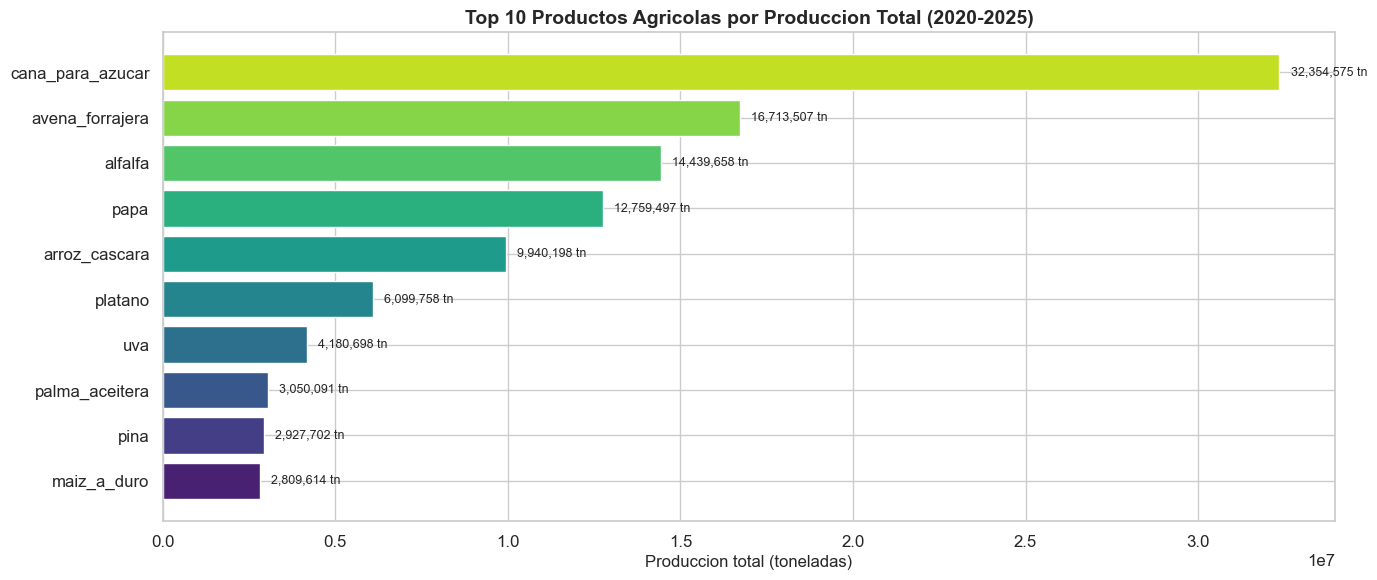

In [17]:
prod_total = df_mensual[prod_cols].sum().sort_values(ascending=False)
top10 = prod_total.head(10)

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette("viridis", n_colors=10)
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=colors)
ax.set_xlabel("Produccion total (toneladas)", fontsize=12)
ax.set_title("Top 10 Productos Agricolas por Produccion Total (2020-2025)", fontsize=14, fontweight="bold")
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + prod_total.max()*0.01, bar.get_y() + bar.get_height()/2,
            f"{val:,.0f} tn", va="center", fontsize=9)
plt.tight_layout()
plt.show()


**Interpretacion:** La cana de azucar domina la produccion total con 32.3M de toneladas, casi el doble que la avena forrajera (16.7M) y la alfalfa (14.4M). Esto refleja la importancia de los cultivos agroindustriales y forrajeros en la produccion nacional. La papa (12.7M) y el arroz cascara (9.9M) son los principales cultivos alimentarios, mientras que la uva (4.2M) y la palma aceitera (3.0M) representan los cultivos de agroexportacion. Se observa una alta concentracion: los 3 primeros productos representan mas del 48% de la produccion total.

## Grafico 2 --- Produccion total por region

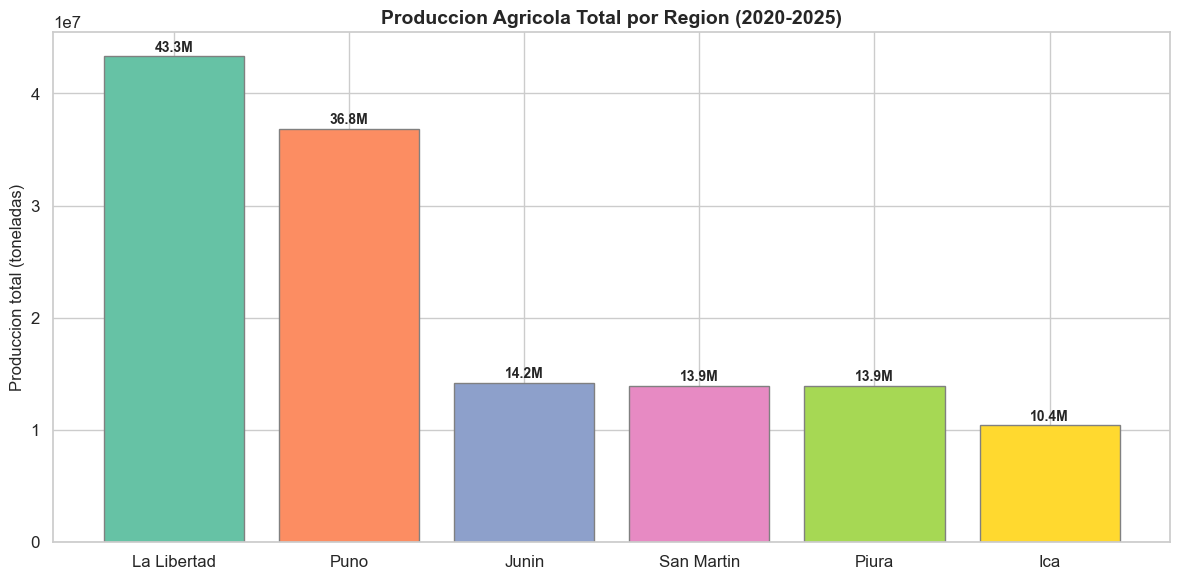

In [18]:
df_mensual["prod_total"] = df_mensual[prod_cols].sum(axis=1)
prod_region = df_mensual.groupby("region")["prod_total"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("Set2", n_colors=6)
bars = ax.bar(prod_region.index, prod_region.values, color=colors, edgecolor="gray")
ax.set_ylabel("Produccion total (toneladas)", fontsize=12)
ax.set_title("Produccion Agricola Total por Region (2020-2025)", fontsize=14, fontweight="bold")
for bar, val in zip(bars, prod_region.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + prod_region.max()*0.01,
            f"{val/1e6:.1f}M", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


**Interpretacion:** La Libertad lidera con 43.3M de toneladas, impulsada por la cana de azucar y la papa. Puno ocupa el segundo lugar (36.8M) gracias a los cultivos forrajeros (avena, alfalfa) que dominan la sierra. Junin, San Martin y Piura tienen volumenes similares (~14M cada uno), mientras que Ica produce menos en volumen (10.4M) pero con productos de alto valor como uva y esparrago. Esta distribucion evidencia que el volumen no refleja necesariamente el valor economico de la produccion.

## Grafico 3 --- Heatmap de estacionalidad: produccion mensual por region

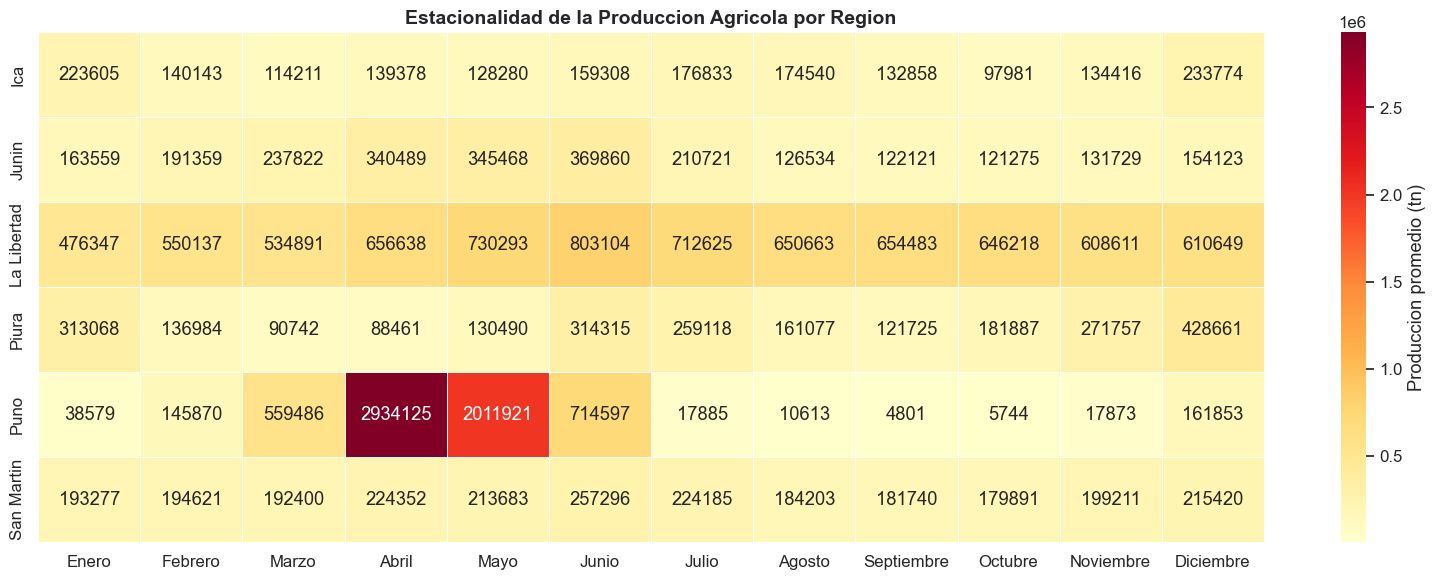

In [19]:
orden_meses = ["Enero","Febrero","Marzo","Abril","Mayo","Junio",
               "Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]
pivot = df_mensual.groupby(["region", "mes"])["prod_total"].mean().unstack()
pivot = pivot[orden_meses]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Produccion promedio (tn)"}, ax=ax)
ax.set_title("Estacionalidad de la Produccion Agricola por Region", fontsize=14, fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


**Interpretacion:** Se observan patrones estacionales marcados por region:
- **Puno** presenta la estacionalidad mas extrema: produccion masiva en Abril (2.9M tn, cosecha principal de papa y forrajeros) vs casi nula en Septiembre (4,800 tn), reflejando un ciclo agricola definido por lluvias y heladas.
- **La Libertad** mantiene produccion relativamente estable con pico en Junio (803K tn) por la cosecha de cana.
- **Piura** muestra alta variabilidad con pico en Diciembre (429K tn) asociado a arroz y mango.
- **Ica** y **San Martin** son las regiones mas estables a lo largo del ano.

## Grafico 4 --- Distribucion de variables climaticas clave por region

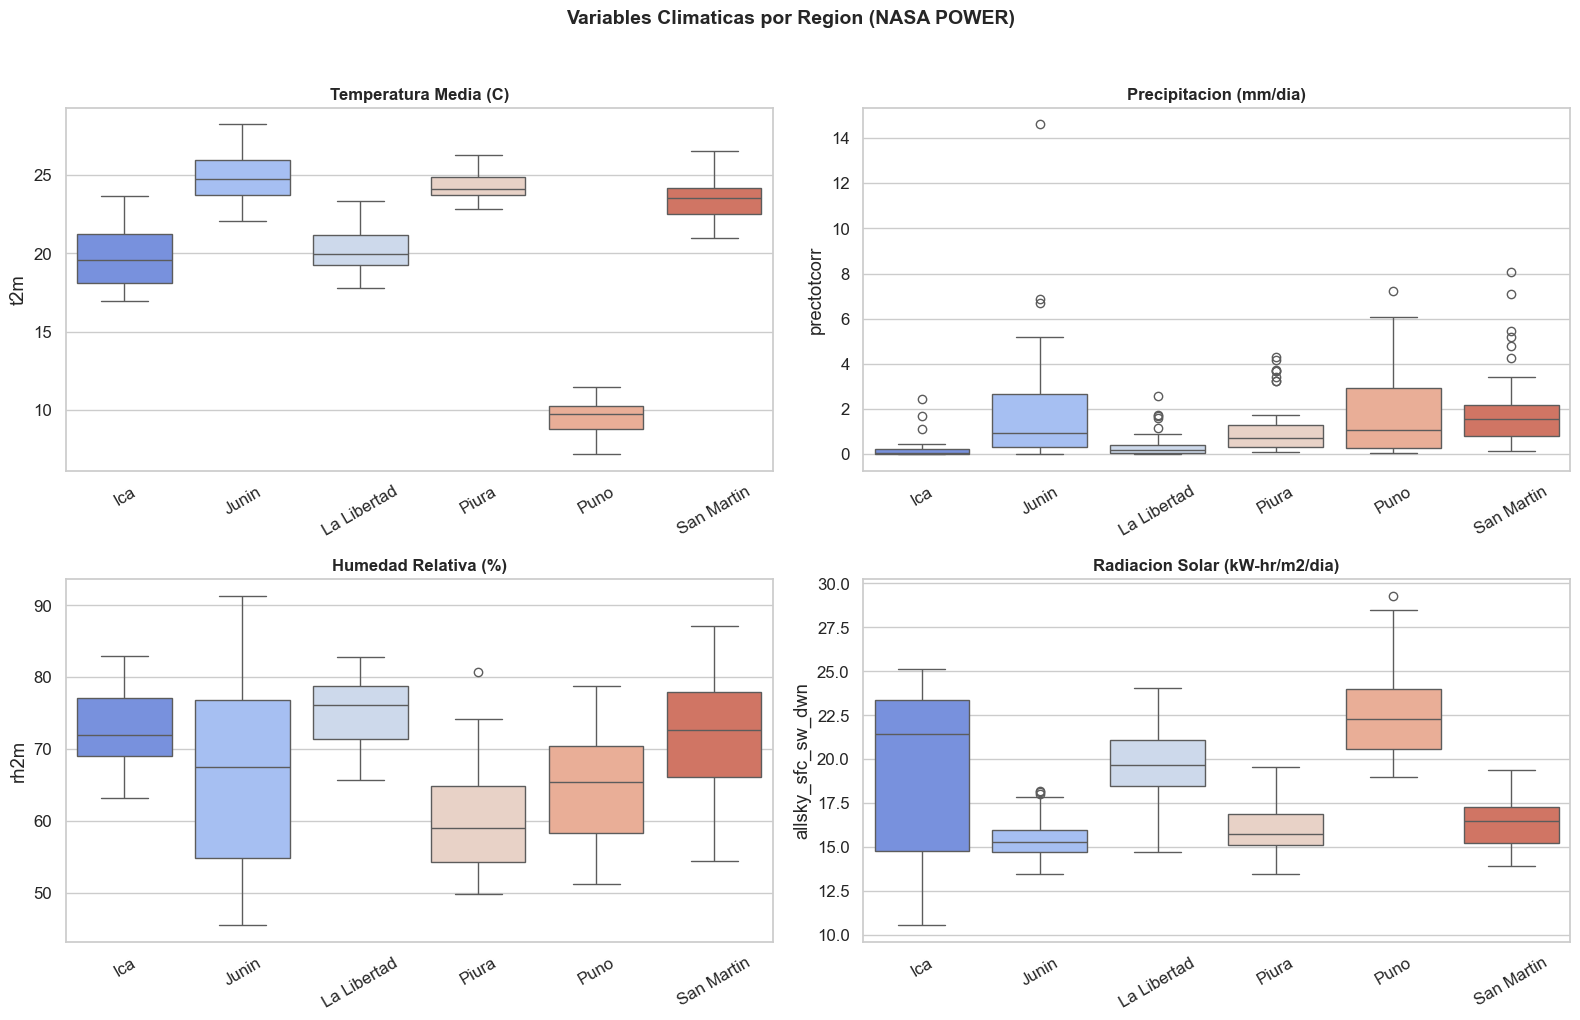

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
vars_clima = [("t2m", "Temperatura Media (C)"), ("prectotcorr", "Precipitacion (mm/dia)"),
              ("rh2m", "Humedad Relativa (%)"), ("allsky_sfc_sw_dwn", "Radiacion Solar (kW-hr/m2/dia)")]

for ax, (var, titulo) in zip(axes.flat, vars_clima):
    sns.boxplot(data=df_mensual, x="region", y=var, ax=ax, palette="coolwarm")
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Variables Climaticas por Region (NASA POWER)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Interpretacion:** Las variables climaticas muestran diferencias drasticas entre regiones:
- **Temperatura:** Puno es la region mas fria (9.6 C promedio), contrastando con Junin (24.9 C) y Piura (24.3 C). Piura tiene la menor variabilidad termica (std=0.8 C), clima muy estable.
- **Precipitacion:** Ica es la mas arida (0.2 mm/dia), mientras que Junin y San Martin reciben las mayores lluvias (1.8 mm/dia). Esto explica la dependencia de Ica del riego tecnificado.
- **Humedad:** La Libertad tiene la mayor humedad relativa (75%), mientras que Piura es la mas seca (60.2%).
- **Radiacion:** Puno recibe la mayor radiacion solar por su altitud (>3,800 msnm) y baja nubosidad.

## Grafico 5 --- Correlacion entre variables climaticas y produccion total

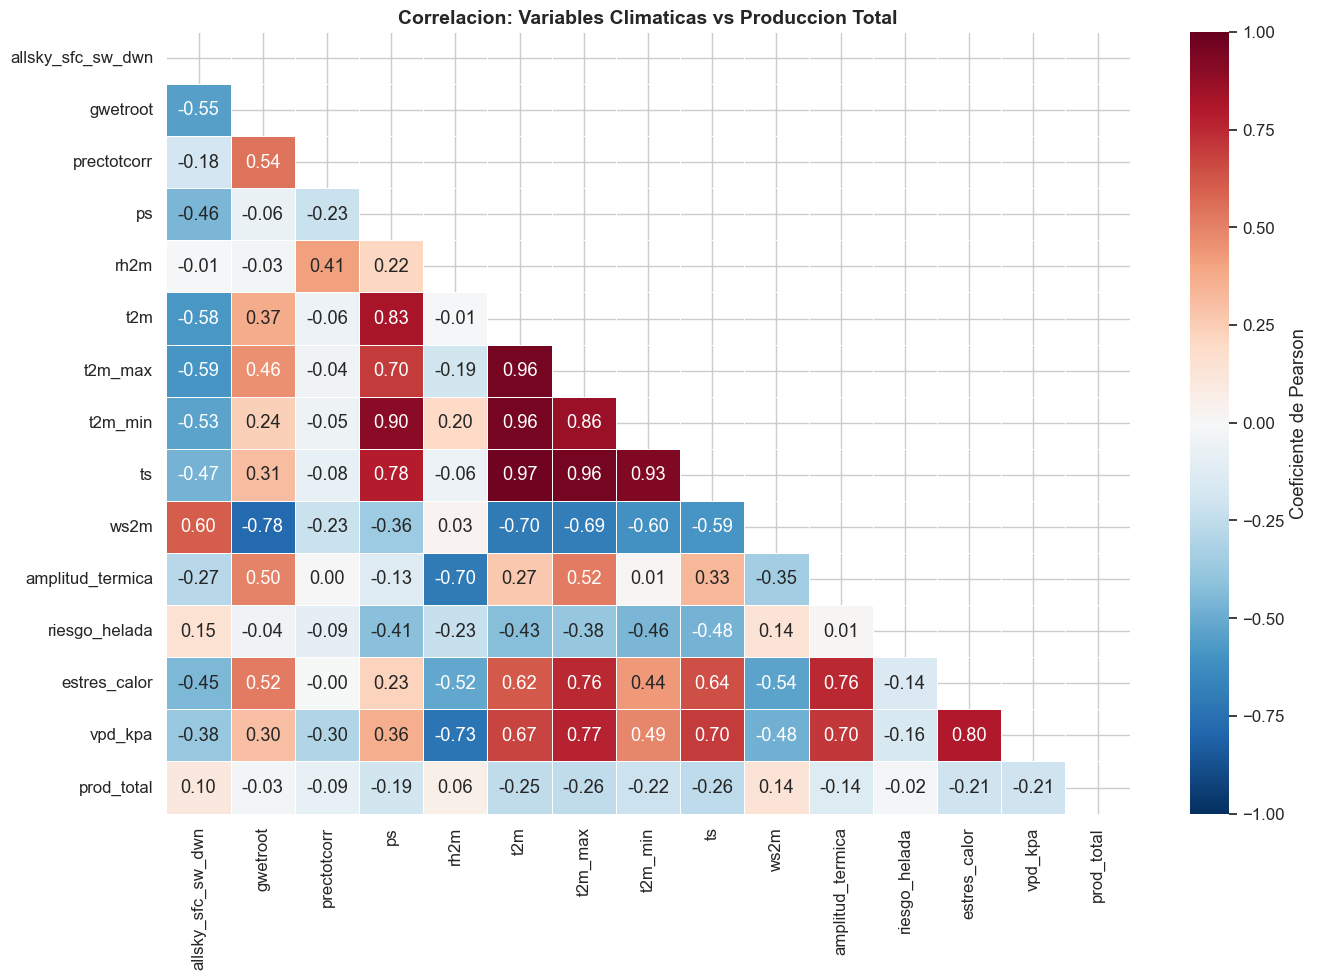

In [21]:
corr_cols = clima_cols + ["prod_total"]
corr_matrix = df_mensual[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={"label": "Coeficiente de Pearson"})
ax.set_title("Correlacion: Variables Climaticas vs Produccion Total", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Interpretacion:** Las correlaciones entre clima y produccion total son debiles a moderadas:
- Las variables de **temperatura** (t2m=-0.25, t2m_max=-0.26, ts=-0.26) muestran correlacion negativa, lo que sugiere que regiones mas frias (Puno) tienden a tener mayor produccion total en volumen, explicado por los cultivos forrajeros extensivos.
- El **estres por calor** (-0.21) y el **VPD** (-0.21) tambien son negativos, coherente con lo anterior.
- La **precipitacion** (-0.09) y la **humedad** (0.06) muestran correlacion casi nula con la produccion agregada. Esto no significa que el clima no influye, sino que el efecto se diluye al agregar todos los productos. El Grafico 10 analiza la correlacion producto por producto.

## Grafico 6 --- Evolucion temporal de la produccion por region

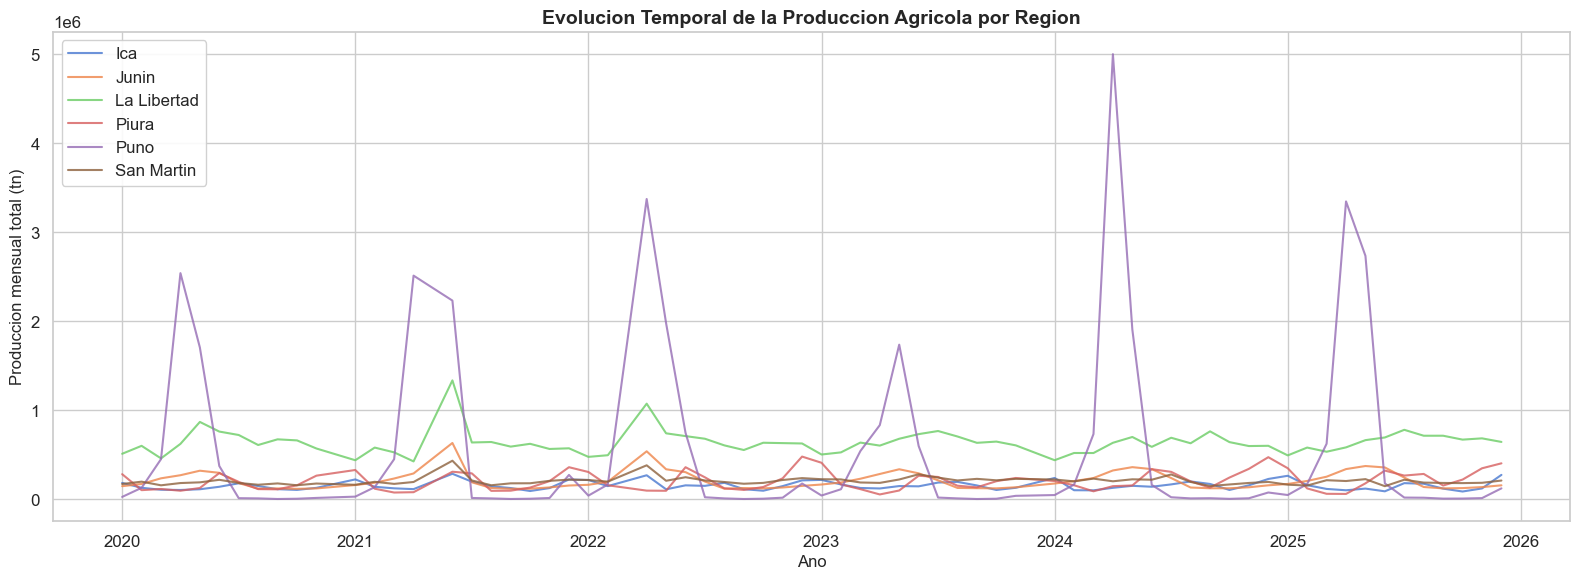

In [22]:
mes_to_num = {m: i+1 for i, m in enumerate(orden_meses)}
df_mensual["fecha_num"] = df_mensual["anos"] + (df_mensual["mes"].map(mes_to_num) - 1) / 12

fig, ax = plt.subplots(figsize=(16, 6))
for region in df_mensual["region"].unique():
    sub = df_mensual[df_mensual["region"] == region].sort_values("fecha_num")
    ax.plot(sub["fecha_num"], sub["prod_total"], label=region, alpha=0.8, linewidth=1.5)

ax.set_xlabel("Ano", fontsize=12)
ax.set_ylabel("Produccion mensual total (tn)", fontsize=12)
ax.set_title("Evolucion Temporal de la Produccion Agricola por Region", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()


**Interpretacion:** La evolucion temporal muestra:
- **Puno** presenta los picos estacionales mas pronunciados (patron dientes de sierra), con produccion concentrada en los meses de cosecha (Mar-May) y casi nula en invierno.
- **La Libertad** es la region mas estable en produccion, con niveles consistentemente altos.
- No se observa una tendencia clara de crecimiento o decrecimiento interanual en ninguna region, sugiriendo que la produccion se mantiene en niveles similares entre 2020 y 2025.
- Los datos de 2025 estan incompletos (solo hasta los meses disponibles).

## Grafico 7 --- Top 5 productos por region (especializacion agricola)

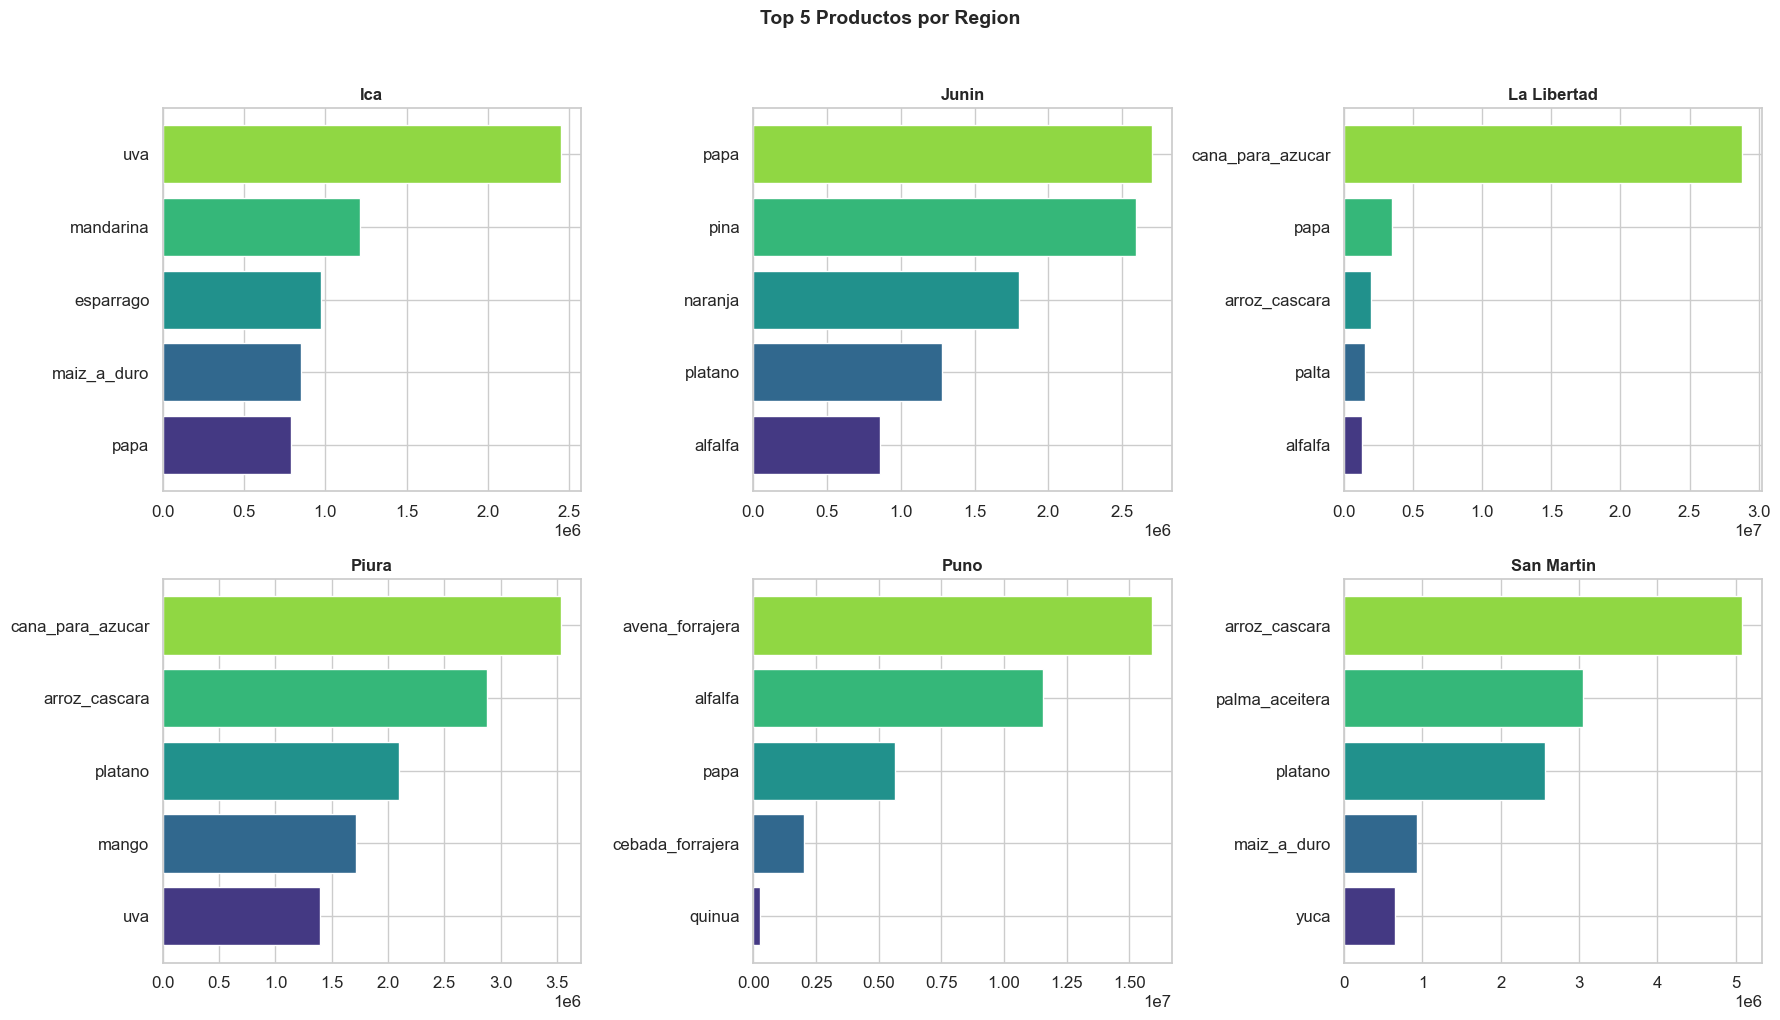

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
regiones = sorted(df_mensual["region"].unique())

for ax, reg in zip(axes.flat, regiones):
    sub = df_mensual[df_mensual["region"] == reg][prod_cols].sum().sort_values(ascending=False).head(5)
    colors = sns.color_palette("viridis", n_colors=5)
    ax.barh(sub.index[::-1], sub.values[::-1], color=colors)
    ax.set_title(reg, fontsize=12, fontweight="bold")
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0,0))

fig.suptitle("Top 5 Productos por Region", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Interpretacion:** Cada region tiene un perfil productivo claramente diferenciado:
- **Ica:** Uva, mandarina, esparrago -- perfil agroexportador de alto valor.
- **Junin:** Papa, pina, naranja -- diversidad de pisos ecologicos (sierra y selva central).
- **La Libertad:** Cana de azucar, papa, arroz -- perfil agroindustrial y alimentario.
- **Piura:** Cana de azucar, arroz, platano, mango -- agricultura tropical e industrial.
- **Puno:** Avena forrajera, alfalfa, papa -- economia ganadera y cultivos de autoconsumo.
- **San Martin:** Arroz, palma aceitera, platano -- agricultura de selva tropical.

Esta especializacion justifica el uso de clustering para agrupar regiones con perfiles similares.

## Grafico 8 --- Relacion Temperatura vs Produccion por region

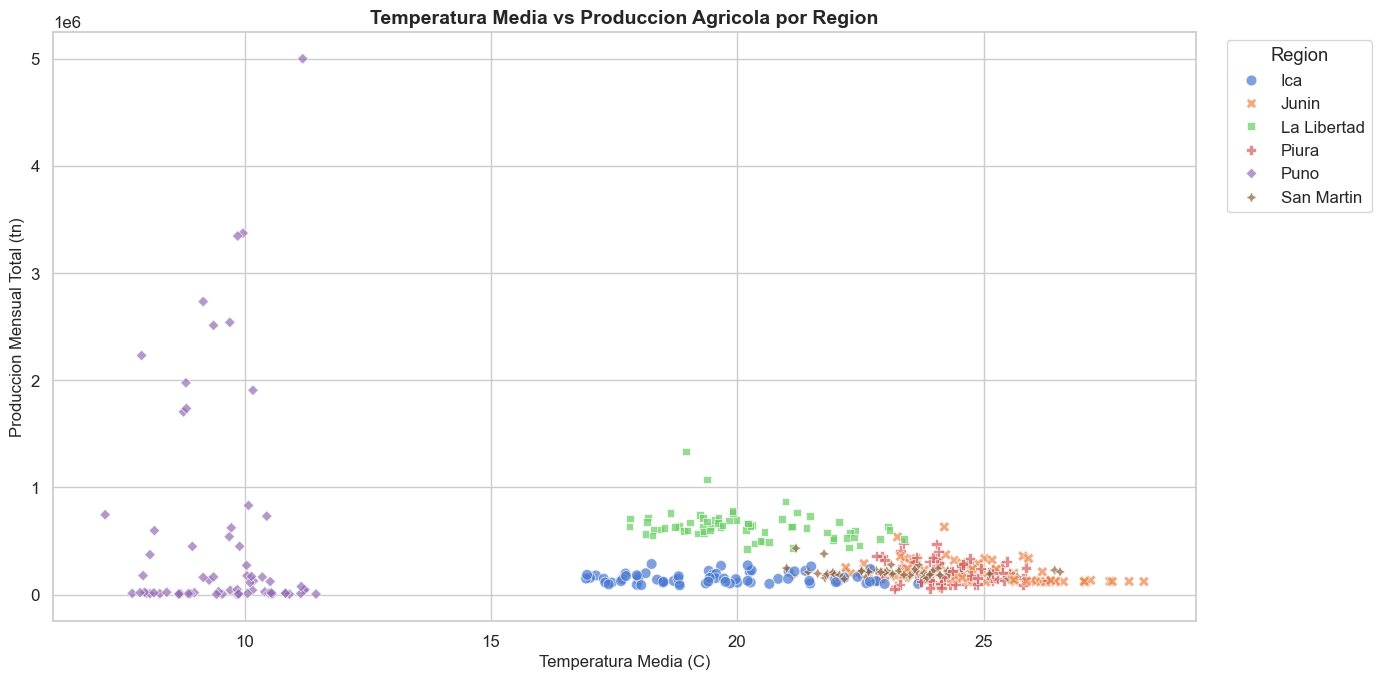

In [24]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.scatterplot(data=df_mensual, x="t2m", y="prod_total", hue="region",
                style="region", s=60, alpha=0.7, ax=ax)
ax.set_xlabel("Temperatura Media (C)", fontsize=12)
ax.set_ylabel("Produccion Mensual Total (tn)", fontsize=12)
ax.set_title("Temperatura Media vs Produccion Agricola por Region", fontsize=14, fontweight="bold")
ax.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Interpretacion:** El scatter plot revela tres agrupaciones naturales:
- **Puno (8-12 C):** Se separa del resto con bajas temperaturas y alta variabilidad en produccion. Los puntos altos corresponden a los meses de cosecha (Abr-May).
- **Ica y La Libertad (17-24 C):** Temperaturas moderadas con produccion intermedia.
- **Junin, Piura, San Martin (22-27 C):** Temperaturas altas con produccion variable.

No se observa una relacion lineal clara entre temperatura y produccion a nivel agregado, lo que confirma que la relacion clima-produccion es especifica por producto y region.

## Grafico 9 --- Patron estacional de precipitacion y temperatura

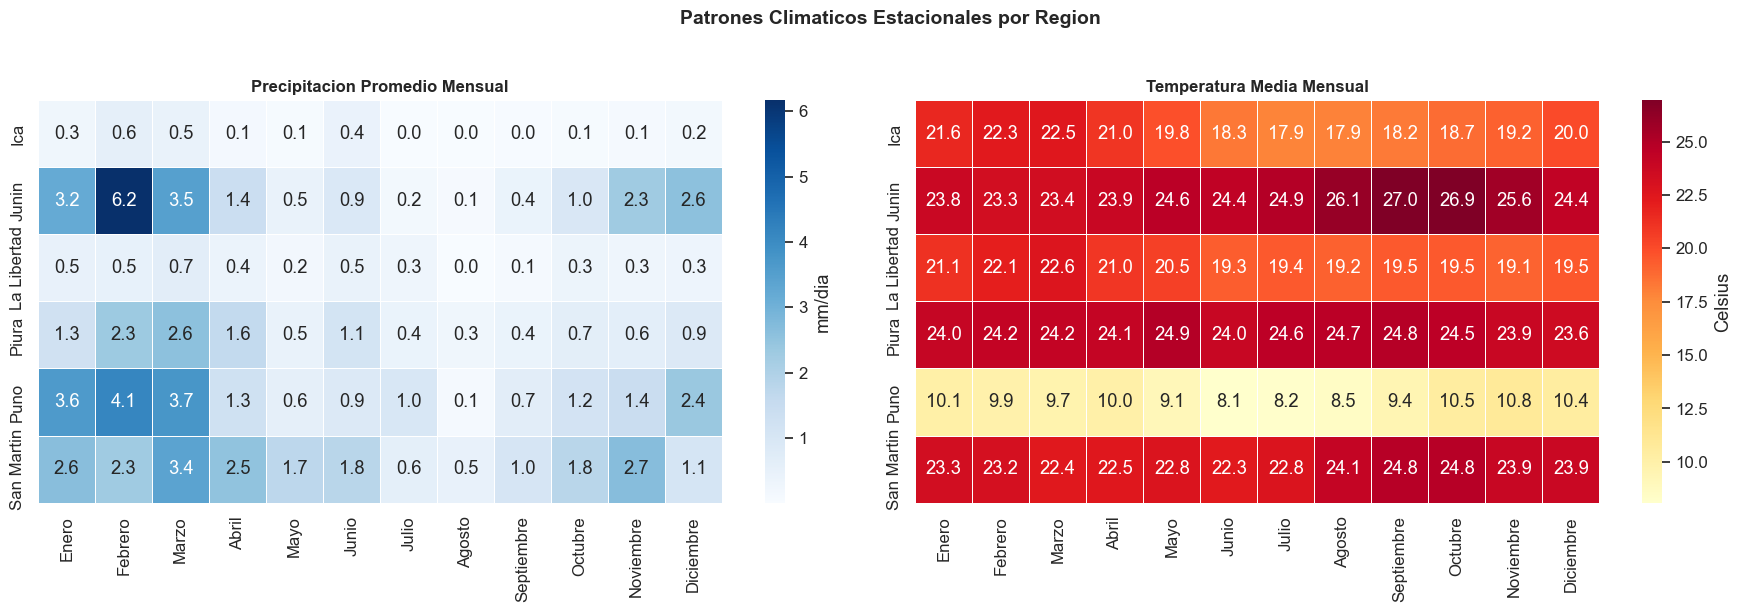

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Precipitacion por mes y region
pivot_prec = df_mensual.groupby(["region", "mes"])["prectotcorr"].mean().unstack()
pivot_prec = pivot_prec[orden_meses]
sns.heatmap(pivot_prec, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5, ax=ax1,
            cbar_kws={"label": "mm/dia"})
ax1.set_title("Precipitacion Promedio Mensual", fontsize=12, fontweight="bold")
ax1.set_ylabel("")
ax1.set_xlabel("")

# Temperatura por mes y region
pivot_temp = df_mensual.groupby(["region", "mes"])["t2m"].mean().unstack()
pivot_temp = pivot_temp[orden_meses]
sns.heatmap(pivot_temp, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5, ax=ax2,
            cbar_kws={"label": "Celsius"})
ax2.set_title("Temperatura Media Mensual", fontsize=12, fontweight="bold")
ax2.set_ylabel("")
ax2.set_xlabel("")

fig.suptitle("Patrones Climaticos Estacionales por Region", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Interpretacion:** Los heatmaps climaticos estacionales revelan:
- **Precipitacion:** San Martin y Junin tienen lluvias concentradas en Dic-Mar (>3 mm/dia), mientras que Ica tiene precipitacion casi nula todo el ano (<0.5 mm/dia). Puno muestra un patron clasico de temporada humeda (Dic-Mar) vs seca (May-Sep).
- **Temperatura:** Puno es consistentemente la region mas fria (7-11 C). Piura tiene la temperatura mas estable (23-26 C todo el ano). Junin presenta las temperaturas mas altas (24-27 C) por la ubicacion del distrito de Pangoa en selva.

Estos patrones climaticos determinan directamente los calendarios de siembra y cosecha.

## Grafico 10 --- Correlacion de los 10 principales productos con variables climaticas

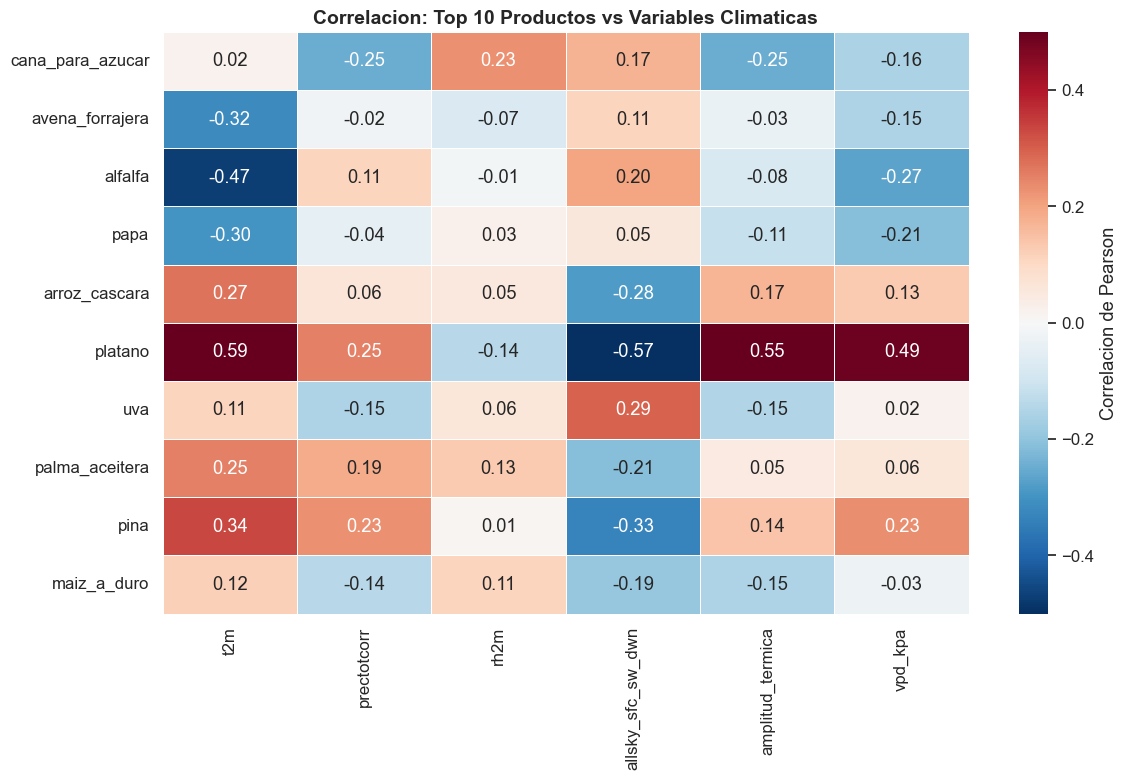

In [26]:
top10_prods = df_mensual[prod_cols].sum().sort_values(ascending=False).head(10).index.tolist()
clima_principales = ["t2m", "prectotcorr", "rh2m", "allsky_sfc_sw_dwn", "amplitud_termica", "vpd_kpa"]

corr_top = df_mensual[top10_prods + clima_principales].corr().loc[top10_prods, clima_principales]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_top, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax, vmin=-0.5, vmax=0.5,
            cbar_kws={"label": "Correlacion de Pearson"})
ax.set_title("Correlacion: Top 10 Productos vs Variables Climaticas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Interpretacion:** El analisis producto-por-producto revela correlaciones mas informativas que el agregado:
- Los **cultivos forrajeros** (alfalfa, avena, cebada forrajera) tienden a correlacionarse negativamente con temperatura, lo que confirma su concentracion en regiones frias como Puno.
- El **arroz cascara** puede mostrar correlacion con precipitacion, coherente con sus requerimientos hidricos.
- La **cana de azucar** se asocia con regiones de temperatura moderada y baja precipitacion directa (riego).
- Los productos de agroexportacion (uva, esparrago) muestran patrones independientes del clima local, ya que dependen de riego tecnificado (Ica).

Estas correlaciones seran clave para seleccionar variables predictoras en la fase de modelado.

## Grafico 11 --- Frecuencia de riesgo de helada y estres por calor por region

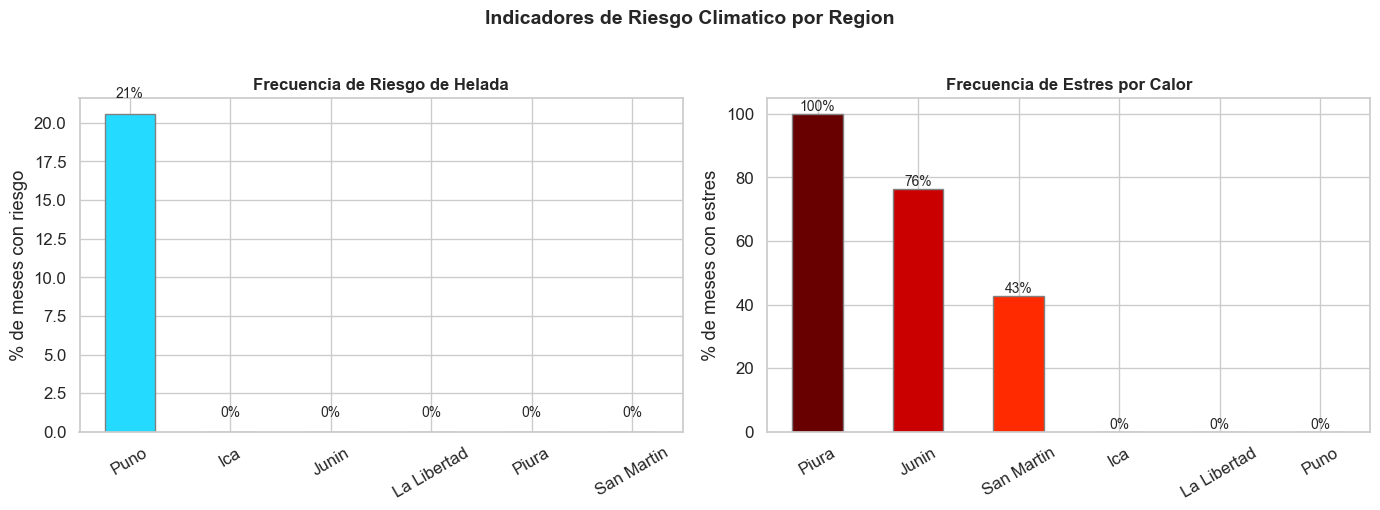

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

helada = df_mensual.groupby("region")["riesgo_helada"].mean() * 100
calor = df_mensual.groupby("region")["estres_calor"].mean() * 100

helada.sort_values(ascending=False).plot(kind="bar", ax=ax1, color=sns.color_palette("cool", 6), edgecolor="gray")
ax1.set_title("Frecuencia de Riesgo de Helada", fontsize=12, fontweight="bold")
ax1.set_ylabel("% de meses con riesgo")
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=30)
for i, v in enumerate(helada.sort_values(ascending=False).values):
    ax1.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=10)

calor.sort_values(ascending=False).plot(kind="bar", ax=ax2, color=sns.color_palette("hot", 6), edgecolor="gray")
ax2.set_title("Frecuencia de Estres por Calor", fontsize=12, fontweight="bold")
ax2.set_ylabel("% de meses con estres")
ax2.set_xlabel("")
ax2.tick_params(axis="x", rotation=30)
for i, v in enumerate(calor.sort_values(ascending=False).values):
    ax2.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=10)

fig.suptitle("Indicadores de Riesgo Climatico por Region", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Interpretacion:** Los indicadores de riesgo climatico muestran una clara diferenciacion:
- **Riesgo de helada:** Solo Puno presenta heladas (21% de los meses), coherente con su altitud (>3,800 msnm). Esto afecta directamente la produccion de papa y quinua, productos sensibles a heladas.
- **Estres por calor:** Piura registra estres calorifico el 100% de los meses, seguido de Junin (76%, por Pangoa en selva) y San Martin (43%). Ica y La Libertad no presentan estres calorifico.

Estos indicadores son variables clave para modelos predictivos de vulnerabilidad agricola.

## Grafico 12 --- Distribucion de la produccion total mensual por region

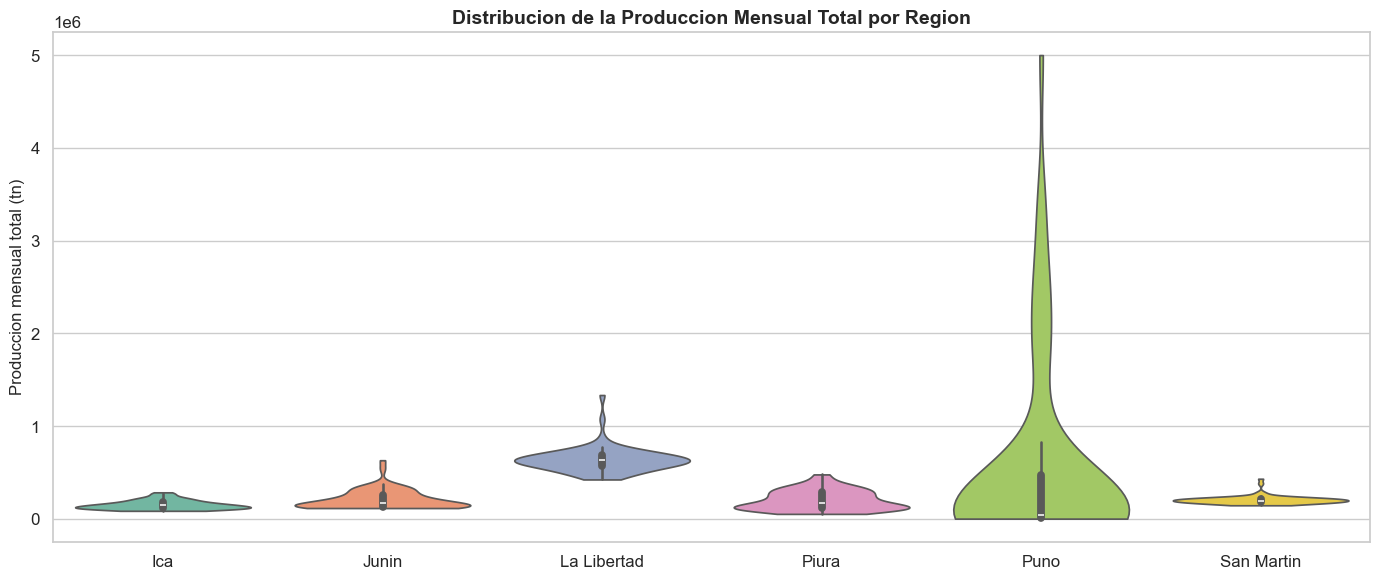

In [28]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=df_mensual, x="region", y="prod_total", palette="Set2",
               inner="box", ax=ax, cut=0)
ax.set_ylabel("Produccion mensual total (tn)", fontsize=12)
ax.set_xlabel("")
ax.set_title("Distribucion de la Produccion Mensual Total por Region", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Limpiar columna auxiliar
df_mensual.drop(columns=["prod_total", "fecha_num"], inplace=True, errors="ignore")


**Interpretacion:** Los violin plots confirman la heterogeneidad productiva:
- **Puno** tiene la distribucion mas amplia y asimetrica, con una cola larga hacia valores altos (meses de cosecha masiva) y una concentracion en valores cercanos a cero (meses de inactividad).
- **La Libertad** presenta la mediana mas alta y una distribucion mas compacta, reflejando produccion sostenida.
- **Ica** es la region con menor variabilidad, indicando produccion agricola mas estable y predecible.

Esta distribucion bimodal en algunas regiones (especialmente Puno) refuerza la decision de no tratar outliers, ya que los valores extremos son patrones estacionales reales.